# Inspect Scene Map: assets/scene_maps/test_map

This notebook explores the contents of the scene map directory used by `SpatialMemory`.


In [1]:
import os
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Set the scene map directory relative to the repo root.
# The notebook lives under notebook/, so go up one level.
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebook":
    REPO_ROOT = REPO_ROOT.parent

SCENE_MAP_DIR = REPO_ROOT / "assets" / "scene_maps" / "test_map"
print("Repo root:", REPO_ROOT.resolve())
print("Scene map directory:", SCENE_MAP_DIR.resolve())
print("Exists:", SCENE_MAP_DIR.exists())

Repo root: /home/ubadmin/projects/dimensional-applications/dimos
Scene map directory: /home/ubadmin/projects/dimensional-applications/dimos/assets/scene_maps/test_map
Exists: True


In [2]:
# Recursively list all files and subdirectories
all_files = []
for root, dirs, files in os.walk(SCENE_MAP_DIR):
    for f in files:
        full_path = Path(root) / f
        all_files.append({
            "path": str(full_path),
            "relative": str(full_path.relative_to(SCENE_MAP_DIR)),
            "size_bytes": full_path.stat().st_size,
            "ext": full_path.suffix.lower(),
        })

print(f"Found {len(all_files)} files under {SCENE_MAP_DIR}\n")
for item in all_files:
    print(item["relative"], "→", item["size_bytes"], "bytes")


Found 5 files under /home/ubadmin/projects/dimensional-applications/dimos/assets/scene_maps/test_map

chromadb_data/chroma.sqlite3 → 475136 bytes
chromadb_data/9bb860bb-697a-46c9-bbfe-40553699bc55/link_lists.bin → 0 bytes
chromadb_data/9bb860bb-697a-46c9-bbfe-40553699bc55/length.bin → 400 bytes
chromadb_data/9bb860bb-697a-46c9-bbfe-40553699bc55/header.bin → 100 bytes
chromadb_data/9bb860bb-697a-46c9-bbfe-40553699bc55/data_level0.bin → 218800 bytes


File extension counts:
ext
.bin        4
.sqlite3    1
Name: count, dtype: int64

Total size per extension (bytes):
ext
.sqlite3    475136
.bin        219300
Name: size_bytes, dtype: int64


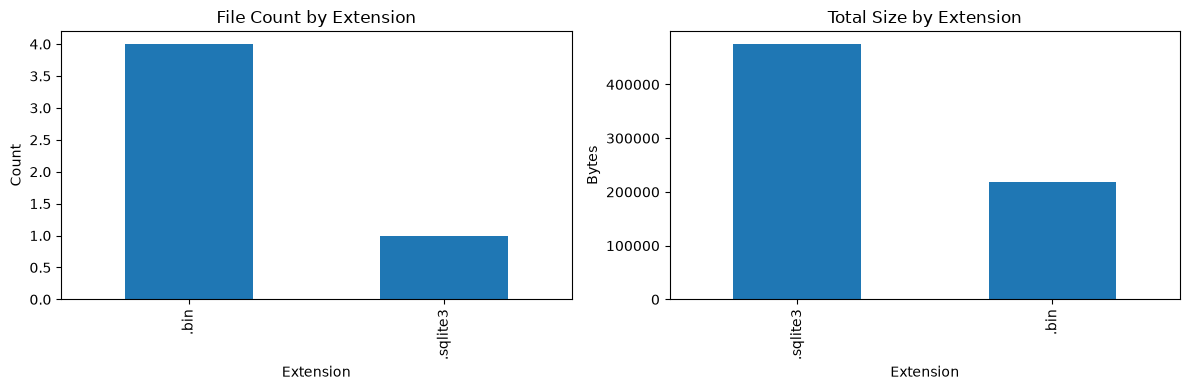

In [3]:
# Analyze file types and sizes
df = pd.DataFrame(all_files)
if df.empty:
    print("No files found.")
else:
    # File extension distribution
    ext_counts = df["ext"].value_counts()
    print("File extension counts:")
    print(ext_counts)

    # Total size per extension
    ext_sizes = df.groupby("ext")["size_bytes"].sum().sort_values(ascending=False)
    print("\nTotal size per extension (bytes):")
    print(ext_sizes)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ext_counts.plot(kind="bar", ax=axes[0], title="File Count by Extension")
    axes[0].set_xlabel("Extension")
    axes[0].set_ylabel("Count")
    ext_sizes.plot(kind="bar", ax=axes[1], title="Total Size by Extension")
    axes[1].set_xlabel("Extension")
    axes[1].set_ylabel("Bytes")
    plt.tight_layout()
    plt.show()


In [4]:
# Read any JSON/YAML/text configuration files
config_files = [p for p in all_files if p["ext"] in (".json", ".yaml", ".yml", ".txt", ".md")]
print(f"Found {len(config_files)} config/text files.\n")

for item in config_files:
    path = Path(item["path"])
    print("=" * 60)
    print(path.relative_to(SCENE_MAP_DIR))
    print("=" * 60)
    try:
        if path.suffix.lower() == ".json":
            data = json.loads(path.read_text())
            print(json.dumps(data, indent=2, ensure_ascii=False)[:2000])
        else:
            print(path.read_text()[:2000])
    except Exception as e:
        print("Error reading file:", e)
    print("\n")


Found 0 config/text files.



In [5]:
# Read and display image files (PNG, JPG, JPEG, etc.)
image_files = [p for p in all_files if p["ext"] in (".png", ".jpg", ".jpeg", ".bmp", ".gif")]
print(f"Found {len(image_files)} image files.\n")

for item in image_files[:5]:  # show first 5 images
    path = Path(item["path"])
    try:
        img = Image.open(path)
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(str(path.relative_to(SCENE_MAP_DIR)))
        plt.axis("off")
        plt.show()
        print(f"  Size: {img.size}, Mode: {img.mode}, File: {path.name}\n")
    except Exception as e:
        print(f"Error loading {path}: {e}")


Found 0 image files.



In [6]:
# Read tabular data files (CSV, TSV, etc.)
table_files = [p for p in all_files if p["ext"] in (".csv", ".tsv")]
print(f"Found {len(table_files)} table files.\n")

for item in table_files:
    path = Path(item["path"])
    try:
        sep = "\t" if path.suffix.lower() == ".tsv" else ","
        tbl = pd.read_csv(path, sep=sep)
        print("=" * 60)
        print(path.relative_to(SCENE_MAP_DIR))
        print("=" * 60)
        print(tbl.head())
        print(tbl.info())
    except Exception as e:
        print(f"Error reading {path}: {e}")


Found 0 table files.



In [7]:
# Summarize findings
print("=" * 60)
print("Scene Map Summary")
print("=" * 60)
print(f"Directory: {SCENE_MAP_DIR.resolve()}")
print(f"Total files: {len(all_files)}")
if not df.empty:
    print(f"Total size: {df['size_bytes'].sum():,} bytes ({df['size_bytes'].sum() / (1024*1024):.2f} MB)")
    print("\nFile extensions:")
    for ext, count in ext_counts.items():
        print(f"  {ext or '(no ext)'}: {count} files")
    print("\nLargest files:")
    for _, row in df.nlargest(5, "size_bytes").iterrows():
        print(f"  {row['relative']} ({row['size_bytes']:,} bytes)")
print("\nConfig/text files:", [Path(p["path"]).name for p in config_files])
print("Image files:", [Path(p["path"]).name for p in image_files])
print("Table files:", [Path(p["path"]).name for p in table_files])


Scene Map Summary
Directory: /home/ubadmin/projects/dimensional-applications/dimos/assets/scene_maps/test_map
Total files: 5
Total size: 694,436 bytes (0.66 MB)

File extensions:
  .bin: 4 files
  .sqlite3: 1 files

Largest files:
  chromadb_data/chroma.sqlite3 (475,136 bytes)
  chromadb_data/9bb860bb-697a-46c9-bbfe-40553699bc55/data_level0.bin (218,800 bytes)
  chromadb_data/9bb860bb-697a-46c9-bbfe-40553699bc55/length.bin (400 bytes)
  chromadb_data/9bb860bb-697a-46c9-bbfe-40553699bc55/header.bin (100 bytes)
  chromadb_data/9bb860bb-697a-46c9-bbfe-40553699bc55/link_lists.bin (0 bytes)

Config/text files: []
Image files: []
Table files: []


In [8]:
# Inspect the ChromaDB contents inside the scene map
import sqlite3

chroma_db_path = SCENE_MAP_DIR / "chromadb_data" / "chroma.sqlite3"
print("ChromaDB path:", chroma_db_path)
print("Exists:", chroma_db_path.exists())

if chroma_db_path.exists():
    conn = sqlite3.connect(str(chroma_db_path))
    cursor = conn.cursor()

    # List tables
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [row[0] for row in cursor.fetchall()]
    print("\nTables in chroma.sqlite3:")
    for t in tables:
        print("  -", t)

    # Show collection metadata
    try:
        cursor.execute("SELECT id, name, dimension, database_id FROM collections;")
        collections = cursor.fetchall()
        print("\nCollections:")
        for c in collections:
            print(f"  id={c[0]}, name={c[1]}, dimension={c[2]}, database_id={c[3]}")
    except Exception as e:
        print("Could not read collections table:", e)

    # Count embeddings
    try:
        cursor.execute("SELECT COUNT(*) FROM embeddings;")
        count = cursor.fetchone()[0]
        print(f"\nTotal embeddings in DB: {count}")
    except Exception as e:
        print("Could not count embeddings:", e)

    # Peek at a few embeddings with metadata
    try:
        cursor.execute("""
            SELECT e.id, e.segment_id, e.embedding, m.key, m.string_value, m.int_value, m.float_value
            FROM embeddings e
            LEFT JOIN embedding_metadata m ON e.id = m.id
            LIMIT 20;
        """)
        rows = cursor.fetchall()
        print("\nSample embeddings + metadata (first 20 rows):")
        for r in rows:
            print(r)
    except Exception as e:
        print("Could not read embeddings/metadata:", e)

    conn.close()
else:
    print("No chroma.sqlite3 found; skipping DB inspection.")


ChromaDB path: /home/ubadmin/projects/dimensional-applications/dimos/assets/scene_maps/test_map/chromadb_data/chroma.sqlite3
Exists: True

Tables in chroma.sqlite3:
  - migrations
  - acquire_write
  - collection_metadata
  - segment_metadata
  - tenants
  - databases
  - collections
  - maintenance_log
  - segments
  - embeddings
  - embedding_metadata
  - max_seq_id
  - embedding_fulltext_search
  - embedding_fulltext_search_data
  - embedding_fulltext_search_idx
  - embedding_fulltext_search_content
  - embedding_fulltext_search_docsize
  - embedding_fulltext_search_config
  - embedding_metadata_array
  - embeddings_queue
  - embeddings_queue_config

Collections:
  id=2a35f2e2-edd7-4658-be65-f0466b124858, name=spatial_memory, dimension=512, database_id=00000000-0000-0000-0000-000000000000
  id=c47bf1ce-15c5-4041-afb3-7875dd49f266, name=spatial_memory_locations, dimension=None, database_id=00000000-0000-0000-0000-000000000000

Total embeddings in DB: 57
Could not read embeddings/meta

In [9]:
# Try loading the collection via the ChromaDB client to show semantic contents
try:
    import chromadb

    client = chromadb.PersistentClient(path=str(SCENE_MAP_DIR / "chromadb_data"))
    print("ChromaDB collections:", client.list_collections())

    for col_name in client.list_collections():
        collection = client.get_collection(name=col_name)
        count = collection.count()
        print(f"\nCollection '{col_name}': {count} items")

        if count > 0:
            # Peek at first 3 records
            peek = collection.peek(limit=3)
            print("\nPeek (ids):", peek.get("ids"))
            print("Metadata sample:", peek.get("metadatas"))
            print("Document sample:", peek.get("documents"))
            print("Embedding shape sample:", [len(e) if e else 0 for e in peek.get("embeddings", [])])

            # Try a text query if the collection has documents
            if peek.get("documents"):
                query_doc = peek["documents"][0]
                print("\nQuerying similar to first document...")
                results = collection.query(query_texts=[query_doc], n_results=3)
                print("Query ids:", results.get("ids"))
                print("Query distances:", results.get("distances"))
                print("Query documents:", results.get("documents"))
except Exception as e:
    print("ChromaDB client inspection failed:", e)


ChromaDB collections: [Collection(name=spatial_memory), Collection(name=spatial_memory_locations)]
ChromaDB client inspection failed: argument 'name': 'Collection' object cannot be converted to 'PyString'
